# ✨ Colab Settings

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Alejandro-ZZ/coastal-segmentation/blob/master/ResUnet_workflow.ipynb)

In [ ]:
import os
from google.colab import drive

# Define the Google Drive paths
drive_dir = "/content/drive"
working_dir = f"{drive_dir}/MyDrive/coastal-segmentation"
drive.mount(drive_dir)

# Change the current working directory
assert os.path.exists(working_dir), f"Working directory not found: {working_dir}"
os.chdir(working_dir)
print("Current working dir:", os.getcwd())

In [2]:
# GPU information
!nvidia-smi

Fri Aug 21 01:18:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# GPU current usage
!df -h /dev/shm

Filesystem      Size  Used Avail Use% Mounted on
shm             5.7G     0  5.7G   0% /dev/shm


# ✨ Project Config

In [39]:
#@title ✔️ Imports


import json
import matplotlib.pyplot as plt
import numpy

from pathlib import Path
from typing import Callable
from typing import Optional
from typing import List
from typing import Tuple
from typing import Union

import tensorflow as tf
import tf_keras

print(f"""
Package versions

      TensorFlow (tf): {tf.__version__}
     TensorFlow-Keras: {tf_keras.__version__}
                Numpy: {numpy.__version__}
""")


Package versions

      TensorFlow (tf): 2.20.0
     TensorFlow-Keras: 2.20.0
                Numpy: 2.0.2



In [38]:
#@title ✔️ Constants

# Project paths relative to the working directory
ANNOTATIONS_PATH = Path("assets/annotations/FRF_Duck")
TRAINING_PATH = Path("results/unet_training")

# Expected image dimensions for the model input
# Resize images to 512x512 for training
INPUT_SIZE = 512

# Mapping array index represents the original class, value represents the new class
# Original --> 0:bg, 1:wetsand, 2:drysand, 3:veg, 4:heavies, 5:lag
#   Target --> 0:bg, 1:sand, 2:veg, 3:lag
CLASS_MAPPING = tf.constant(value=[0, 1, 1, 2, 1, 3], dtype=tf.int32)
SMALL_CLASSES = ["background", "sand", "vegetation", "lag"]

# Training params
BATCH_SIZE = 16
NUM_CLASSES = 4 # 0: background, 1: sand, 2: vegetation, 3: lag

# ✨ Functions

In [37]:
#@title ✔️ Helper


# Taking from "coastal-segmentation" repository
def compute_metrics_from_cm(cm: numpy.ndarray, class_names: List[str]) -> dict:
    """
    Derives Accuracy, Precision, Recall, F1-Score, and IoU entirely from a Confusion Matrix.
    """
    tp = numpy.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp

    # Suppress division by zero warnings (handled by nan_to_num)
    # with numpy.errstate(divide='ignore', invalid='ignore'):
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)
    iou = tp / (tp + fp + fn)

    # Replace NaNs (caused by 0/0) with 0
    precision = numpy.nan_to_num(precision)
    recall = numpy.nan_to_num(recall)
    f1 = numpy.nan_to_num(f1)
    iou = numpy.nan_to_num(iou)

    # Overall Pixel Accuracy
    total_pixels = numpy.maximum(cm.sum(), 1)
    overall_acc = numpy.trace(cm) / total_pixels

    # Build the report dictionary (matching sklearn format)
    report = {}
    for idx, name in enumerate(class_names):
        report[name] = {
            "precision": float(precision[idx]),
            "recall": float(recall[idx]),
            "f1-score": float(f1[idx]),
            "jaccard": float(iou[idx]),
            "support": int(cm.sum(axis=1)[idx])
        }

    # Macro Averages
    report["macro avg"] = {
        "precision": float(numpy.mean(precision)),
        "recall": float(numpy.mean(recall)),
        "f1-score": float(numpy.mean(f1)),
        "jaccard": float(numpy.mean(iou)),
        "support": int(cm.sum())
    }

    # Weighted Averages
    weights = cm.sum(axis=1)
    total_support = weights.sum()
    if total_support > 0:
        report["weighted avg"] = {
            "precision": float(numpy.average(precision, weights=weights)),
            "recall": float(numpy.average(recall, weights=weights)),
            "f1-score": float(numpy.average(f1, weights=weights)),
            "jaccard": float(numpy.average(iou, weights=weights)),
            "support": int(total_support)
        }

    report["accuracy"] = float(overall_acc)

    return report


def plot_history_metric(
    history_data: dict,
    metric_name: str,
    ax,
    plot_lr: bool = False,
    start_epoch: int = 1
):
    # Calculate the 0-based starting index
    start_idx = max(0, start_epoch - 1)

    # Get and slice values to plot
    train_values = history_data[metric_name][start_idx:]
    val_values = history_data[f"val_{metric_name}"][start_idx:]

    # Generate matching epoch numbers for the x-axis
    epoch_values = range(start_epoch, start_epoch + len(train_values))

    # Plot main metrics
    line1 = ax.plot(epoch_values, train_values, label="Training")
    line2 = ax.plot(epoch_values, val_values, label="Validation")

    # Optional Learning Rate plotting
    if plot_lr:
        # Keras usually stores this as 'lr' or 'learning_rate'
        lr_values = history_data.get("lr", history_data.get("learning_rate"))

        if lr_values is not None:
            # Slice learning rate values to match the plotted epochs
            lr_values = lr_values[start_idx:]

            # Create a second y-axis sharing the same x-axis
            ax2 = ax.twinx()

            # Subtle styling: gray, dotted, low opacity
            line3 = ax2.plot(
                epoch_values, lr_values, ':',
                color="black", alpha=0.7, label="Learning Rate"
            )

            # Subdue the right Y-axis labels and ticks to match the line
            ax2.set_ylabel("Learning Rate", color='gray', alpha=0.6)
            ax2.tick_params(axis='y', colors='gray', labelcolor='gray')

            # Combine legends from both axes so they don't overlap awkwardly
            lines = line1 + line2 + line3
            labels = [l.get_label() for l in lines]
            ax.legend(lines, labels, loc='best')
        else:
            print("Warning: Learning rate data not found in history.")
            ax.legend()
    else:
        ax.legend()

    ax.set_title(metric_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.grid()


In [25]:
#@title ✔️ Data Preparation


def get_data_paths(images_path: Path, labels_path: Path) -> Tuple[List[Path], List[Path]]:
    """
    Get sorted lists of image and label file paths, ensuring that each
    image has a corresponding label.

    Parameters
    ----------
    images_path : Path
        Directory containing the input images (JPG format).

    labels_path : Path
        Directory containing the corresponding label images (PNG format),
        named as "{image_stem}_label.png".

    Returns
    -------
    Tuple[List[Path], List[Path]]
        A tuple containing two lists:
        - List of valid image file paths (Path objects).
        - List of corresponding label file paths (Path objects).
    """
    # Get sorted list of JPG image files in the given images directory (images_path)
    image_files = sorted(images_path.glob("*.jpg"))

    # Output data file paths
    valid_image_files: List[Path] = []
    valid_label_files: List[Path] = []

    for image_file in image_files:
        # Create the label file path
        label_file = labels_path / f"{image_file.stem}_label.png"

        # Check if the label file exists
        if label_file.exists():
            valid_image_files.append(image_file)
            valid_label_files.append(label_file)
        else:
            raise ValueError(f"Label file not found. Image: {image_file}. Expected label: {label_file}")

    return valid_image_files, valid_label_files


def resnet_process_file(
        image_file: Union[Path | str],
        mask_file: Union[Path | str],
        one_hot_encode: bool = False,
        remap_classes: Optional[tf.Tensor] = None
) -> tuple:
    """Apply preprocessing steps to image and masks and return them."""
    # Image
    img = tf.io.read_file(image_file)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, size=[INPUT_SIZE, INPUT_SIZE])
    img = tf.image.per_image_standardization(img) # standardize(img)

    # Mask
    img_mask = tf.io.read_file(mask_file)
    img_mask = tf.image.decode_png(img_mask, channels=1)
    img_mask = tf.image.resize(
        img_mask, size=[INPUT_SIZE, INPUT_SIZE], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )
    img_mask = tf.squeeze(img_mask, axis=-1)
    img_mask = tf.math.minimum(img_mask, NUM_CLASSES - 1) # D_Filter(img_mask)
    # img_mask = tf.keras.utils.to_categorical(img_mask)  # NO graph mode method, see below
    # img_mask = numpy.expand_dims(img_mask, axis=0)

    # The `one_hot_encode` argument is ignored as the one hot encode
    # it is always needed for this Res-Unet case
    # img_mask = tf.cast(img_mask, tf.int32)    # one_hot need integer values
    img_mask = tf.one_hot(img_mask, depth=NUM_CLASSES)

    # Remap classes
    if remap_classes is not None:
        img_mask = tf.cast(img_mask, tf.int32)
        img_mask = tf.gather(remap_classes, img_mask)

    return img, img_mask


def create_dataset(
        image_files: List[Path],
        label_files: List[Path],
        map_func: Callable,
        batch_size: int,
        is_training: bool = False,
        one_hot_encode: bool = False,
        remap_classes: Optional[tf.Tensor] = None
) -> tf.data.Dataset:
    """
    Create a tf.data.Dataset from lists of image and label file paths.

    Parameters
    ----------
    image_files : List[Path]
        List of file paths to the input images.

    label_files : List[Path]
        List of file paths to the corresponding label images.

    map_func : Callable
        A function that takes an image file path and a label file path, processes them,
        and returns a tuple (image, label). This function will be applied to each pair
        of image and label file paths in the dataset.

        NOTE: both `one_hot_encode` and `remap_classes` are passed to `map_func` as keyword arguments.

    batch_size : int
        The number of samples per batch to load.

    is_training : bool, optional
        Whether the dataset is for training. If True, the dataset will be shuffled.

    one_hot_encode : bool, optional
        Whether to apply one-hot encoding to the labels. Note that the `map_func` must
        accept a `one_hot_encode` argument and handle the encoding accordingly.

    remap_classes : tf.Tensor, optional
        A 1D tensor that maps original class indices to new class indices. The index of the
        tensor represents the original class, and the value at that index represents the new class.
        For example, if the original classes are [0, 1, 2, 3, 4, 5] and we want to remap them to
        [0, 1, 1, 2, 1, 3], then remap_classes would be tf.constant([0, 1, 1, 2, 1, 3], dtype=tf.int32).
        Note that the `map_func` must accept a `remap_classes` argument.
    """
    # Need to be converted to string paths for tf.data.Dataset.from_tensor_slices
    image_files_str = [str(path) for path in image_files]
    label_files_str = [str(path) for path in label_files]

    # Map function wrapper to handle one-hot encoding and remapping if needed
    kwargs = {
        "one_hot_encode": one_hot_encode,
        "remap_classes": remap_classes
    }
    new_map_func = lambda img_file, label_file: map_func(
        img_file, label_file, one_hot_encode=one_hot_encode, remap_classes=remap_classes
    )

    # Create a dataset from the lists of image and label file paths
    dataset = tf.data.Dataset.from_tensor_slices((image_files_str, label_files_str))

    # Shuffle imagery for training only
    if is_training:
        dataset = dataset.shuffle(buffer_size=len(image_files))
    dataset = dataset.map(new_map_func, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


In [10]:
#@title ✔️ Custom Classes


# Changes compared to the UNet "CustomMacroF1" class
#   * Uses "tf_keras" instead of "tf.keras" for compatibility when loading model
#   * Include "tf.argmax" to the "y_true" as dataset is outputting One-Hot Encoded masks
class ResnetCustomMacroF1(tf_keras.metrics.Metric):
    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super(ResnetCustomMacroF1, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.cm = self.add_weight(name="cm", shape=(num_classes, num_classes), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(tf.argmax(y_true, axis=-1), [-1]), tf.int32)
        y_pred = tf.cast(tf.reshape(tf.argmax(y_pred, axis=-1), [-1]), tf.int32)
        cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=self.num_classes, dtype=tf.float32)
        self.cm.assign_add(cm)

    def result(self):
        diag = tf.linalg.diag_part(self.cm)
        row_sum = tf.reduce_sum(self.cm, axis=1)  # Actual
        col_sum = tf.reduce_sum(self.cm, axis=0)  # Predicted

        precision = tf.math.divide_no_nan(diag, col_sum)
        recall = tf.math.divide_no_nan(diag, row_sum)

        f1 = tf.math.divide_no_nan(2 * precision * recall, precision + recall)
        return tf.reduce_mean(f1)

    def reset_state(self):
        self.cm.assign(tf.zeros((self.num_classes, self.num_classes)))

    # Required to save the parameters needed in "__init__"
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "num_classes": self.num_classes}



# ✨ ResUNet (*pre-trained*)

Load the Residual UNet model presented on a [Springer Conference paper](https://link.springer.com/chapter/10.1007/978-3-032-15477-4_55) and available in the [Zenodo records](https://zenodo.org/records/7075342).


In [11]:
#@title ✔️ Load model

#Load up the pretrained model
model_path = TRAINING_PATH / "pretrained_resnet/FRF_mar15_remap_fullmodel_model"
res_model = tf_keras.models.load_model(model_path, compile=True)

# Instance of our custom metric
cm_metric = ResnetCustomMacroF1(num_classes=NUM_CLASSES)

# Recompile the model to attach the new custom metric
res_model.compile(
    loss="categorical_crossentropy",
    metrics=[cm_metric]
)

res_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 512, 512, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 512, 512, 7)          91        ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 512, 512, 7)          28        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 conv2d_2 (Conv2D)           (None, 512, 512, 7)          28        ['input_1[0][0]']         

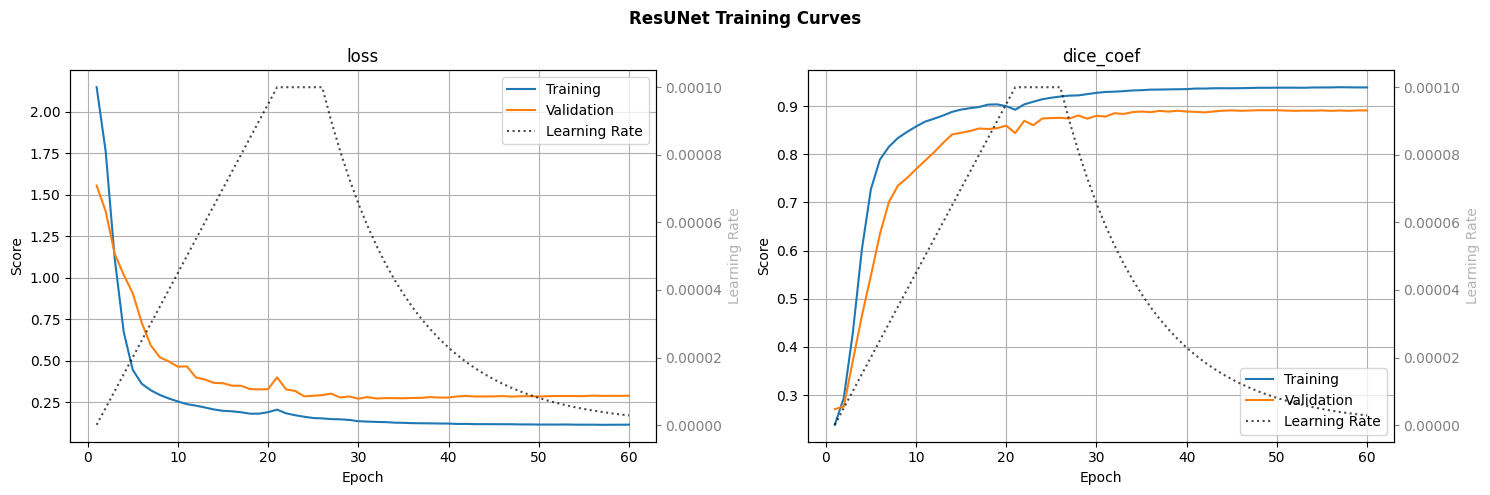

In [36]:
#@title ✔️ Fit History


# Available metrics: loss, mean_iou, dice_coef
history_file = TRAINING_PATH / "pretrained_resnet/FRF_mar15_remap_model_history.npz"
res_history = numpy.load(history_file)


# Plot metrics ---------------------------
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
ax1, ax2 = axs

plot_history_metric(res_history, "loss", ax1, plot_lr=True)
plot_history_metric(res_history, "dice_coef", ax2, plot_lr=True)

fig.suptitle(f"ResUNet Training Curves", fontweight="bold")
plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 253ms/step
  img --> type=EagerTensor, shape=(512, 512, 3), dtype=<dtype: 'float32'>
 mask --> type=EagerTensor, shape=(512, 512, 4), dtype=<dtype: 'float32'>
proba --> type=ndarray, shape=(1, 512, 512, 4), dtype=float32
 pred --> type=ndarray, shape=(512, 512), dtype=int64



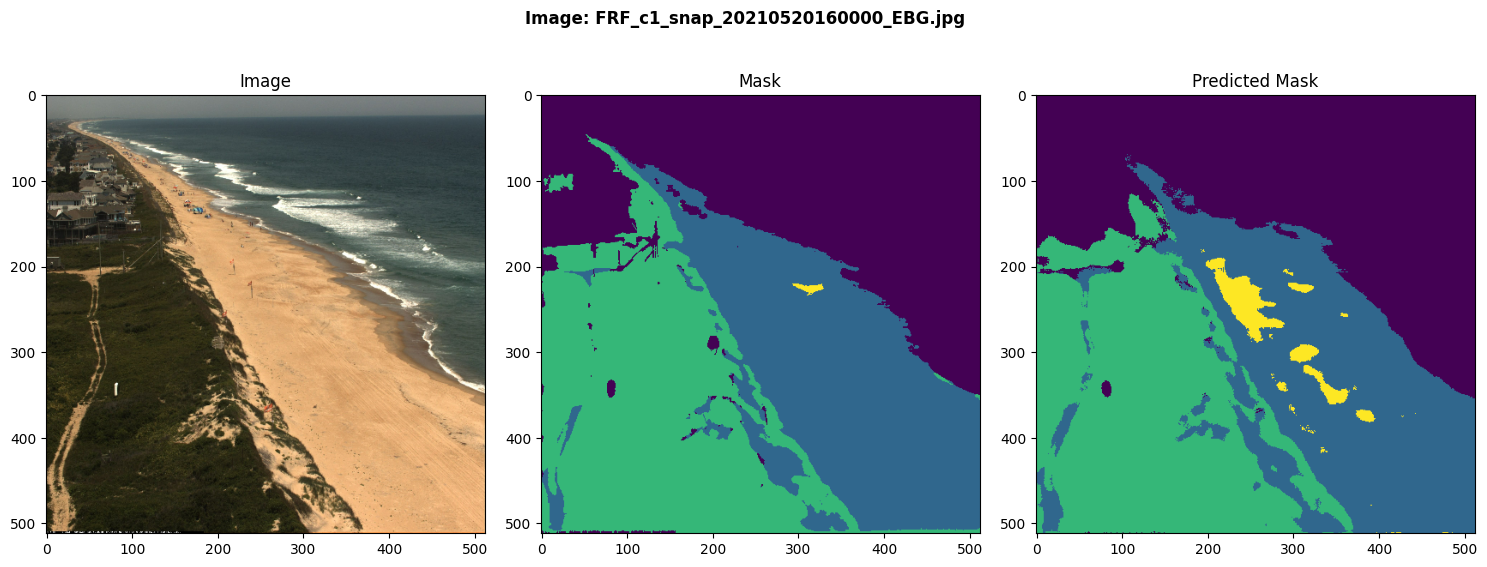

In [27]:
#@title ✔️ Inference test


# Prediction
# ------------------------
# Data files
image_file = ANNOTATIONS_PATH / "test_c1/images/FRF_c1_snap_20210520160000_EBG.jpg"
mask_file = ANNOTATIONS_PATH / "test_c1/labels/FRF_c1_snap_20210520160000_EBG_label.png"

# Preprocess files
img, mask = resnet_process_file(image_file.as_posix(), mask_file.as_posix())

# Make inference
pred_proba = res_model.predict(numpy.expand_dims(img, axis=0))
pred_mask = numpy.argmax(pred_proba.squeeze(), axis=-1)

# Debug variables info: type, shape and dtype
vars = {"  img": img, " mask": mask, "proba": pred_proba, " pred": pred_mask}
for var_name, var_arr in vars.items():
    print(
        f"{var_name} --> type={type(var_arr).__name__}, "
        f"shape={var_arr.shape}, dtype={var_arr.dtype}"
    )
print()


# Display results
# ------------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
ax1, ax2, ax3 = axs

img_display = (img - numpy.min(img)) / (numpy.max(img) - numpy.min(img))
ax1.imshow(img_display)
ax1.set_title(f"Image")
# ax1.axis("off")

ax2.imshow(numpy.argmax(mask, axis=-1))
ax2.set_title(f"Mask")
# ax2.axis("off")

ax3.imshow(pred_mask)
ax3.set_title(f"Predicted Mask")
# ax3.axis("off")

fig.suptitle(f"Image: {image_file.name}", fontweight="bold")
plt.tight_layout()
plt.show()

In [35]:
#@title ✔️ Evaluate and segment


test_dirs = ["test_c1", "test_c6"]  # "train"

for test_dir in test_dirs:
    # Get lists of image and label file paths
    image_files, label_files = get_data_paths(
        images_path=ANNOTATIONS_PATH / f"{test_dir}/images",
        labels_path=ANNOTATIONS_PATH / f"{test_dir}/labels"
    )

    # Create Datasets. Note that One-Hot encode is used as the Res-Unet
    # was compiled using the "CategoricalCrossentropy" loss instead of
    # the "SparseCategoricalCrossentropy" loss
    test_ds = create_dataset(
        image_files=image_files,
        label_files=label_files,
        map_func=resnet_process_file,
        batch_size=BATCH_SIZE,
        is_training=False,
        one_hot_encode=True,    # ignored
        remap_classes=CLASS_MAPPING if test_dir == "train" else None
    )

    # Evaluate model
    print(f"EVALUATION TEST: {test_dir}")
    print("-"*50)
    test_scores = res_model.evaluate(x=test_ds, verbose=1, return_dict=True)
    for metric_name, metric_score in test_scores.items():
        print(f"  * {metric_name}: {metric_score:.2f}")
    print()

    # Compute overall metrics based on accumulated confusion matrix
    final_cm = cm_metric.cm.numpy().astype(numpy.int64)
    overall_metrics = compute_metrics_from_cm(cm=final_cm, class_names=SMALL_CLASSES)

    # Display metrics grouped by class
    print("Metrics grouped by class:")
    for class_name in SMALL_CLASSES:
        f1_score = overall_metrics[class_name]["f1-score"]
        jaccard = overall_metrics[class_name]["jaccard"]
        print(f"  {class_name:>12} --> f1-score={f1_score:.2f}, jaccard={jaccard:.2f}")
    print("  ", "."*45)

    # Display overall macro metrics
    macro_f1 = overall_metrics["macro avg"]["f1-score"]
    macro_jaccard = overall_metrics["macro avg"]["jaccard"]
    print(f"  {'Overall':>12} --> f1-score={macro_f1:.2f}, jaccard={macro_jaccard:.2f}")

    # Save metrics as JSON file
    output_file = Path(f"results/ResUnet_{test_dir}_metrics_overall.json")
    with open(output_file, "w") as f:
        json.dump(overall_metrics, f, indent=4)
    print("Metrics saved as JSON:", output_file)
    print("\n")

EVALUATION TEST: test_c1
--------------------------------------------------
1/1 [==============================] - 1s 885ms/step - loss: 0.2197 - macro_f1: 0.8353
  * loss: 0.22
  * macro_f1: 0.84

Metrics grouped by class:
    background --> f1-score=0.95, jaccard=0.91
          sand --> f1-score=0.91, jaccard=0.83
    vegetation --> f1-score=0.94, jaccard=0.89
           lag --> f1-score=0.53, jaccard=0.37
  .............................................
     Overall --> f1-score=0.84, jaccard=0.75
Metrics saved as JSON: results/ResUnet_test_c1_metrics_overall.json


EVALUATION TEST: test_c6
--------------------------------------------------
1/1 [==============================] - 7s 7s/step - loss: 0.6632 - macro_f1: 0.7003
  * loss: 0.66
  * macro_f1: 0.70

Metrics grouped by class:
    background --> f1-score=0.90, jaccard=0.82
          sand --> f1-score=0.76, jaccard=0.62
    vegetation --> f1-score=0.87, jaccard=0.77
           lag --> f1-score=0.27, jaccard=0.16
  ..............